# Decision Tree Classification — Car Evaluation Dataset

---

## Copyright and License

This Jupyter Notebook is provided for educational and research purposes.

## Disclaimer

This notebook is provided "as is", without warranty of any kind, express or implied.  
All analyses and interpretations are for educational and research purposes only.

## Dataset Note

**Dataset:** Car Evaluation  
**Source:** https://www.kaggle.com/datasets/elikplim/car-evaluation-data-set  
**Locally under:** `../datasets/car_evaluation.csv`  
**License:** CC0: Public Domain

---

## Abstract

Car acceptability classification is a multi-class problem derived from a hierarchical decision model. This notebook presents a reproducible, end-to-end machine learning pipeline applied to the Car Evaluation dataset.

The analysis covers data quality assessment, exploratory data analysis (EDA), preprocessing of categorical features, and the implementation of Decision Tree classifiers using both CART (Gini) and ID3 (Entropy) criteria. Hyperparameter tuning is performed via `GridSearchCV` and `RandomizedSearchCV`. Model performance is evaluated using accuracy, classification report, confusion matrix, and ROC-AUC (OvR).

---

## Executive Summary

Decision Tree models are applied to classify car acceptability across 1,728 records and 6 categorical features. The analysis explores the effect of `criterion`, `max_depth`, `min_samples_split`, `min_samples_leaf`, and `max_features` on model performance. Both `GridSearchCV` and `RandomizedSearchCV` are benchmarked. The best tuned model is visualised and interpreted.

---

## Dataset Relevance

The Car Evaluation dataset originates from a simple hierarchical decision model. It contains 1,728 instances described by 6 categorical attributes and a 4-class target (`unacc`, `acc`, `good`, `vgood`). The class distribution is imbalanced, making it a good testbed for decision trees, which handle categorical data and multi-class targets natively.

---

## Table of Contents

1. [Import Libraries](#1-import-libraries)  
2. [Load Dataset](#2-load-dataset)  
3. [Exploratory Data Analysis](#3-exploratory-data-analysis)  
4. [Preprocessing](#4-preprocessing)  
5. [Baseline Decision Tree](#5-baseline-decision-tree)  
6. [Hyperparameter Tuning — GridSearchCV](#6-hyperparameter-tuning--gridsearchcv)  
7. [Hyperparameter Tuning — RandomizedSearchCV](#7-hyperparameter-tuning--randomizedsearchcv)  
8. [Best Model Evaluation](#8-best-model-evaluation)  
9. [Tree Visualisation](#9-tree-visualisation)  
10. [Feature Importance](#10-feature-importance)  
11. [Conclusions](#11-conclusions)

## 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OrdinalEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score
)

import warnings
warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
np.random.seed(SEED)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

## 2. Load Dataset

In [2]:
# Column names from the UCI Car Evaluation repository
col_names = ['buying', 'maint', 'doors', 'persons', 'lug_boot', 'safety', 'class']

df = pd.read_csv('../datasets/car_evaluation.csv', header=None, names=col_names)
print(f'Shape: {df.shape}')
df.head(10)

Shape: (1728, 7)


,buying,maint,doors,persons,lug_boot,safety,class
0,vhigh,vhigh,2,2,small,low,unacc
1,vhigh,vhigh,2,2,small,med,unacc
2,vhigh,vhigh,2,2,small,high,unacc
3,vhigh,vhigh,2,2,med,low,unacc
4,vhigh,vhigh,2,2,med,med,unacc
5,vhigh,vhigh,2,2,med,high,unacc
6,vhigh,vhigh,2,2,big,low,unacc
7,vhigh,vhigh,2,2,big,med,unacc
8,vhigh,vhigh,2,2,big,high,unacc
9,vhigh,vhigh,2,4,small,low,unacc


## 3. Exploratory Data Analysis

In [3]:
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Unique Values per Column ===')
for col in df.columns:
    print(f'  {col}: {df[col].unique()}')

=== Data Types ===
buying      str
maint       str
doors       str
persons     str
lug_boot    str
safety      str
class       str
dtype: object

=== Missing Values ===
buying      0
maint       0
doors       0
persons     0
lug_boot    0
safety      0
class       0
dtype: int64

=== Unique Values per Column ===
  buying: <StringArray>
['vhigh', 'high', 'med', 'low']
Length: 4, dtype: str
  maint: <StringArray>
['vhigh', 'high', 'med', 'low']
Length: 4, dtype: str
  doors: <StringArray>
['2', '3', '4', '5more']
Length: 4, dtype: str
  persons: <StringArray>
['2', '4', 'more']
Length: 3, dtype: str
  lug_boot: <StringArray>
['small', 'med', 'big']
Length: 3, dtype: str
  safety: <StringArray>
['low', 'med', 'high']
Length: 3, dtype: str
  class: <StringArray>
['unacc', 'acc', 'vgood', 'good']
Length: 4, dtype: str


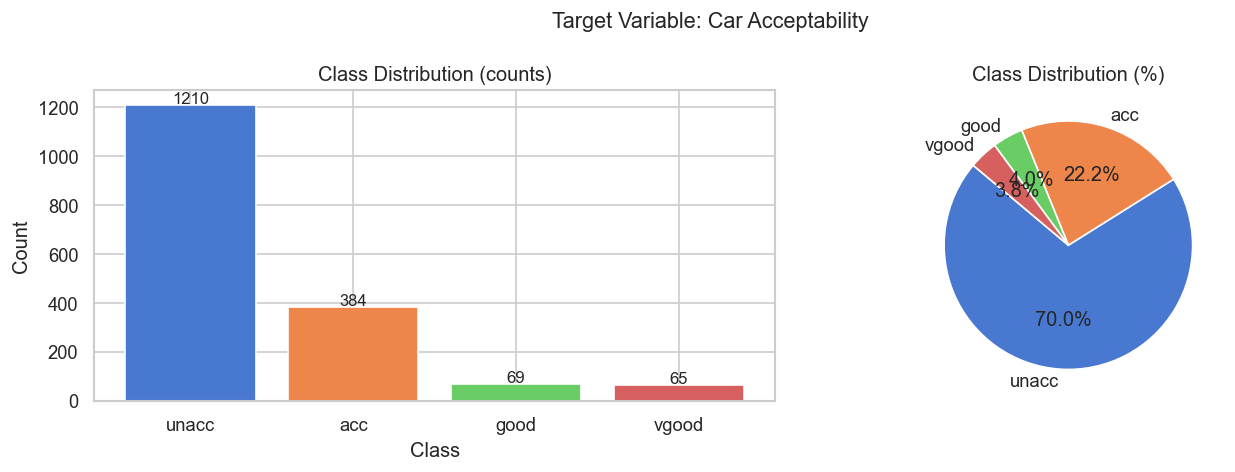

In [4]:
# Target class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

class_counts = df['class'].value_counts()
axes[0].bar(class_counts.index, class_counts.values, color=sns.color_palette('muted'))
axes[0].set_title('Class Distribution (counts)')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontsize=10)

axes[1].pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%',
            colors=sns.color_palette('muted'), startangle=140)
axes[1].set_title('Class Distribution (%)')

plt.suptitle('Target Variable: Car Acceptability', fontsize=13)
plt.tight_layout()
plt.show()

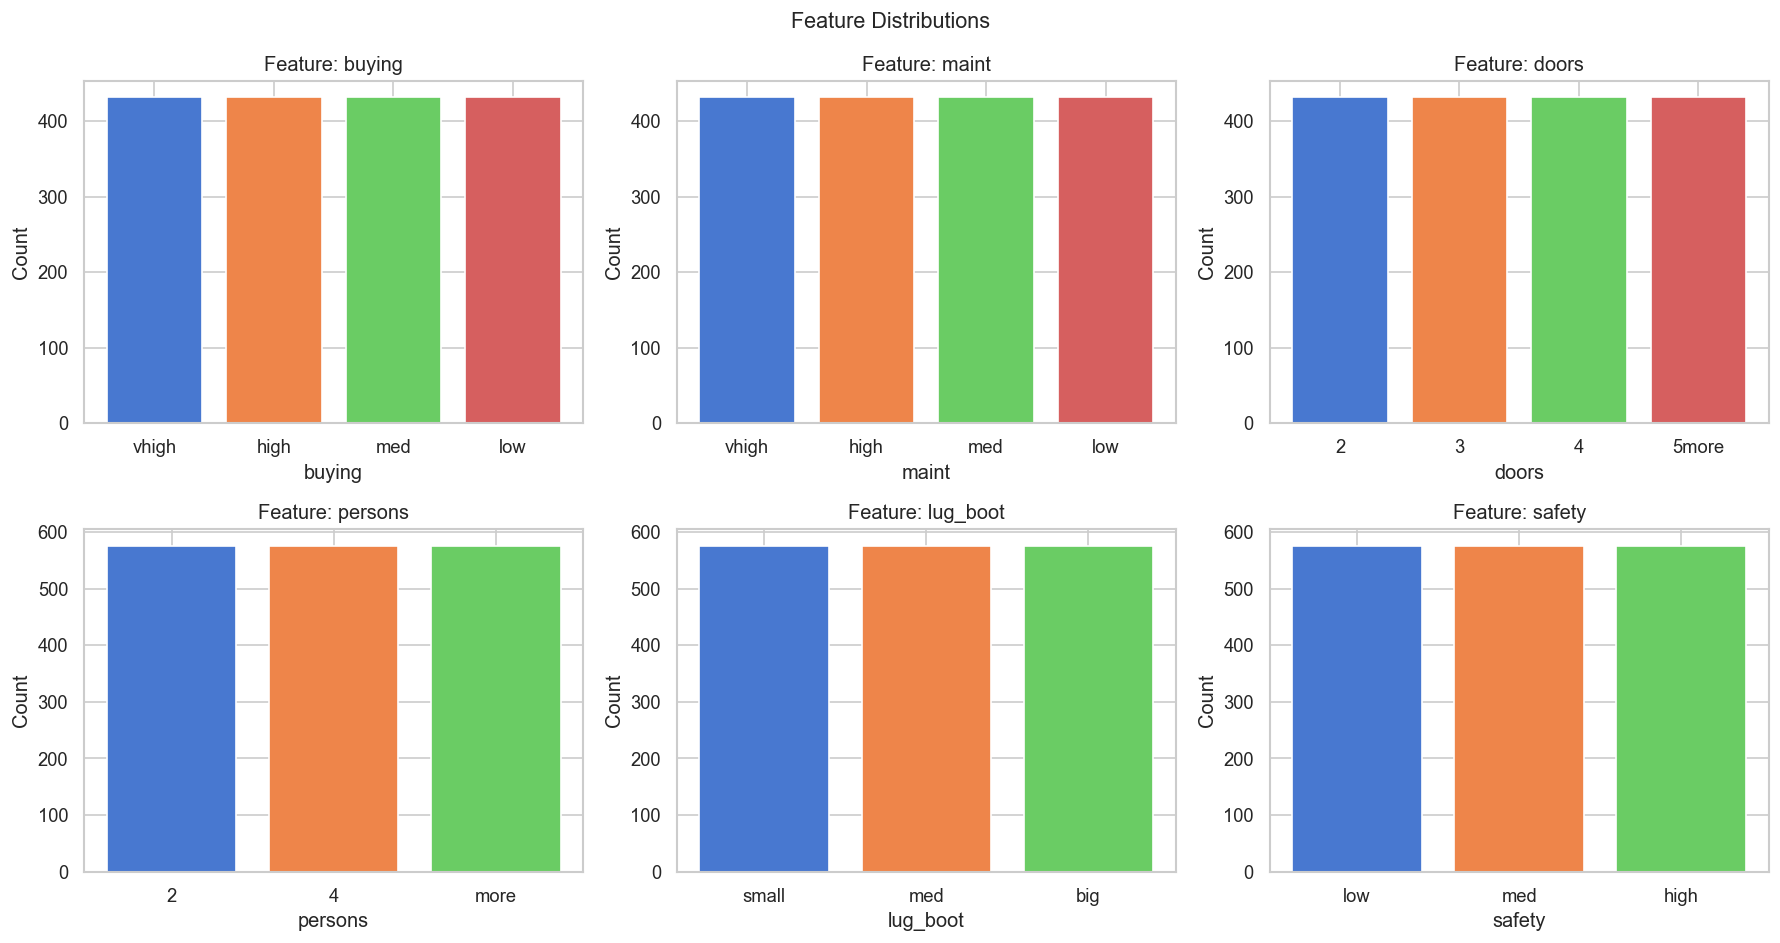

In [5]:
# Feature distributions
features = [c for c in df.columns if c != 'class']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(features):
    counts = df[feat].value_counts()
    axes[i].bar(counts.index, counts.values, color=sns.color_palette('muted'))
    axes[i].set_title(f'Feature: {feat}')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Count')

plt.suptitle('Feature Distributions', fontsize=13)
plt.tight_layout()
plt.show()

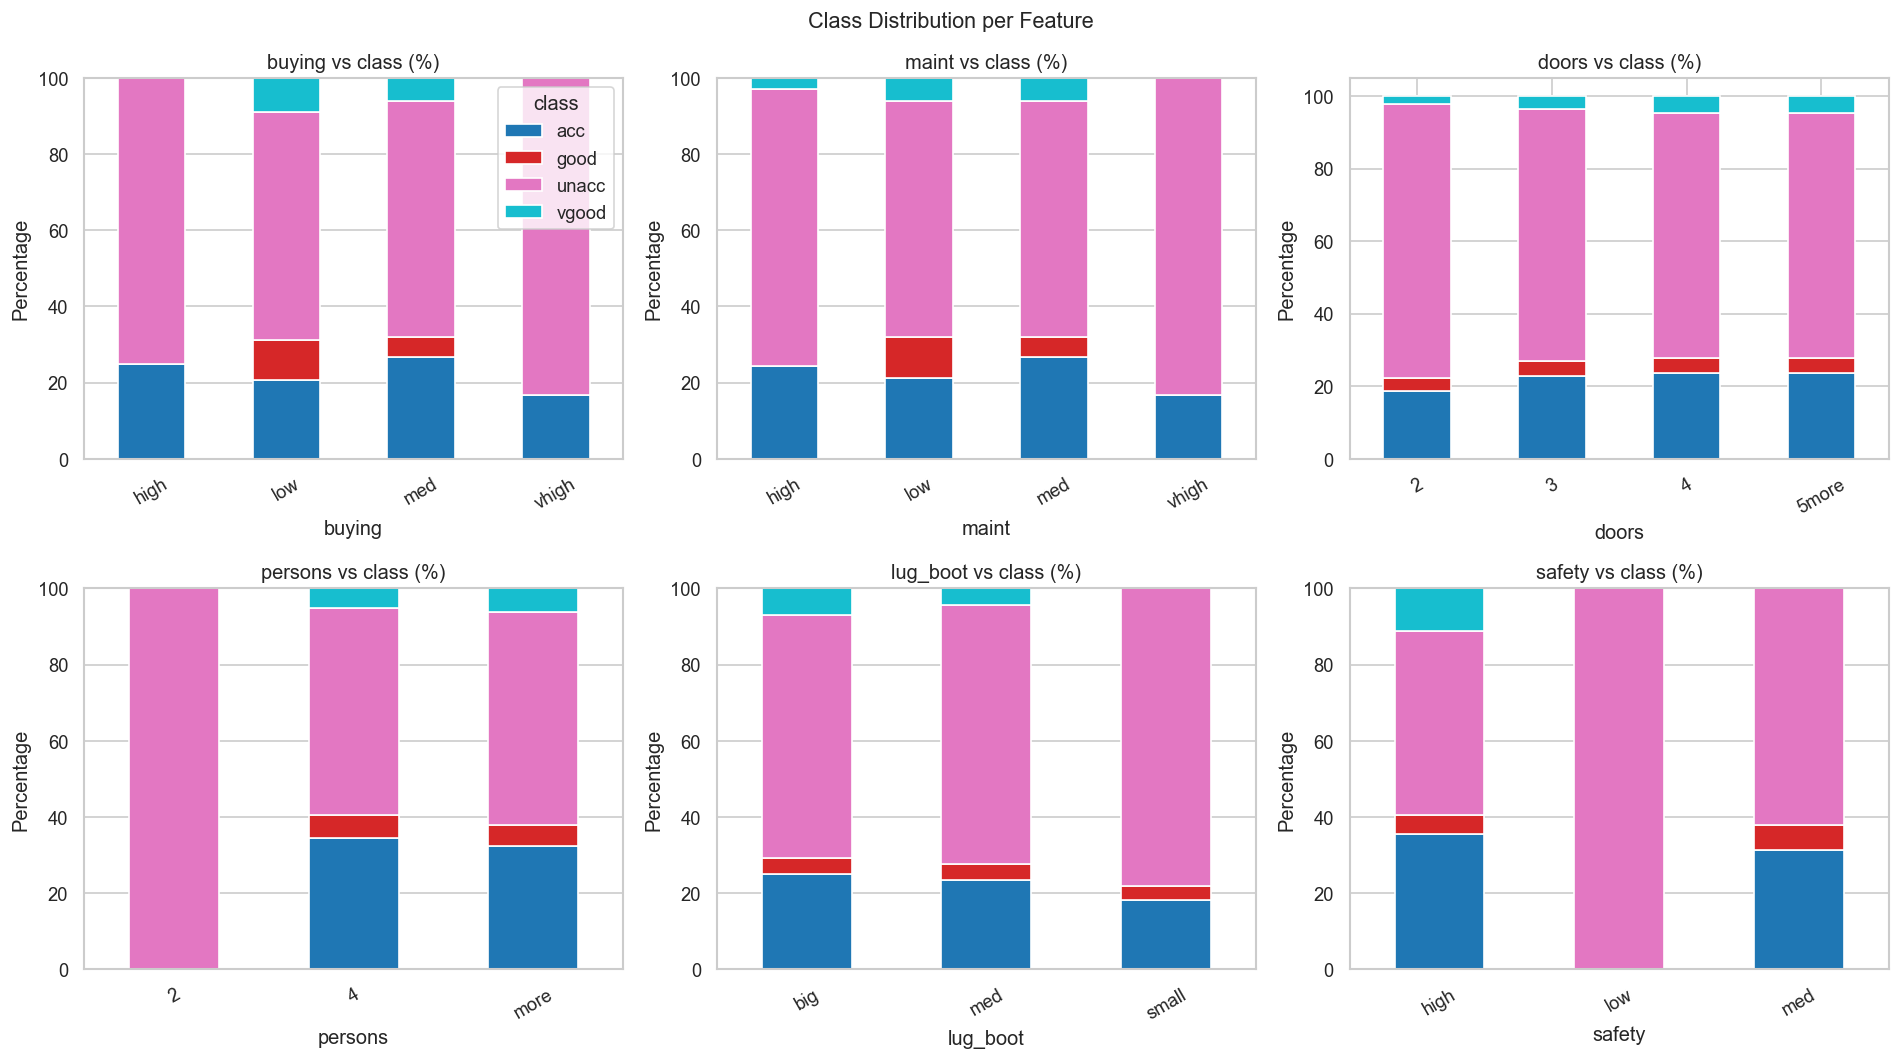

In [6]:
# Class distribution per feature (stacked bar)
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()
classes = df['class'].unique()

for i, feat in enumerate(features):
    ct = pd.crosstab(df[feat], df['class'], normalize='index') * 100
    ct.plot(kind='bar', stacked=True, ax=axes[i], colormap='tab10', legend=(i == 0))
    axes[i].set_title(f'{feat} vs class (%)')
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel('Percentage')
    axes[i].tick_params(axis='x', rotation=30)

plt.suptitle('Class Distribution per Feature', fontsize=13)
plt.tight_layout()
plt.show()

## 4. Preprocessing

In [7]:
# Ordinal encoding preserving natural order for each feature
buying_order   = ['low', 'med', 'high', 'vhigh']
maint_order    = ['low', 'med', 'high', 'vhigh']
doors_order    = ['2', '3', '4', '5more']
persons_order  = ['2', '4', 'more']
lug_order      = ['small', 'med', 'big']
safety_order   = ['low', 'med', 'high']

enc = OrdinalEncoder(
    categories=[buying_order, maint_order, doors_order, persons_order, lug_order, safety_order]
)

X = enc.fit_transform(df[features])
X = pd.DataFrame(X, columns=features)

# Encode target
le = LabelEncoder()
y = le.fit_transform(df['class'])
print('Class mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

# Train / test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print(f'Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}')

Class mapping: {'acc': np.int64(0), 'good': np.int64(1), 'unacc': np.int64(2), 'vgood': np.int64(3)}
Train size: 1382 | Test size: 346


## 5. Baseline Decision Tree

In [8]:
# Baseline model with default hyperparameters
dt_base = DecisionTreeClassifier(random_state=SEED)
dt_base.fit(X_train, y_train)

y_pred_base = dt_base.predict(X_test)
acc_base = accuracy_score(y_test, y_pred_base)

print(f'Baseline Accuracy: {acc_base:.4f}')
print(f'Tree Depth: {dt_base.get_depth()}')
print(f'Number of Leaves: {dt_base.get_n_leaves()}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_base, target_names=le.classes_))

Baseline Accuracy: 0.9913
Tree Depth: 12
Number of Leaves: 81

Classification Report:
              precision    recall  f1-score   support

         acc       0.97      0.99      0.98        77
        good       0.93      1.00      0.97        14
       unacc       1.00      1.00      1.00       242
       vgood       1.00      0.92      0.96        13

    accuracy                           0.99       346
   macro avg       0.98      0.98      0.98       346
weighted avg       0.99      0.99      0.99       346



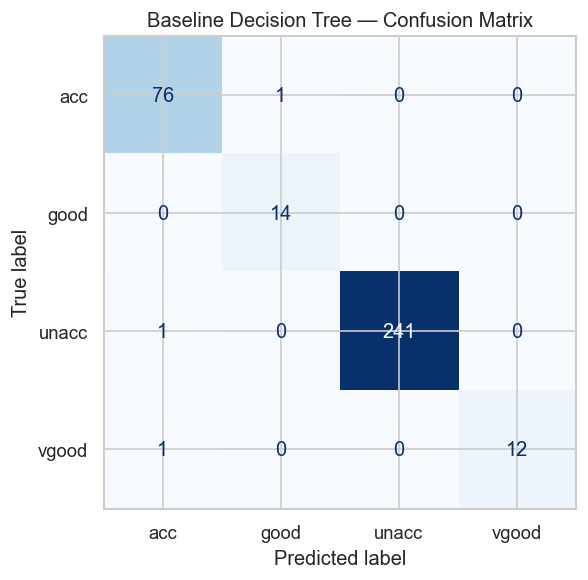

In [9]:
# Baseline confusion matrix
cm = confusion_matrix(y_test, y_pred_base)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Baseline Decision Tree — Confusion Matrix')
plt.tight_layout()
plt.show()

In [10]:
# Cross-validation score on training set
cv_scores = cross_val_score(dt_base, X_train, y_train, cv=5, scoring='accuracy')
print(f'5-Fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

5-Fold CV Accuracy: 0.9754 ± 0.0070


## 6. Hyperparameter Tuning — GridSearchCV

In [11]:
# Parameter grid
param_grid = {
    'criterion':          ['gini', 'entropy'],
    'max_depth':          [3, 5, 7, 10, None],
    'min_samples_split':  [2, 5, 10, 20],
    'min_samples_leaf':   [1, 2, 4, 8],
    'max_features':       [None, 'sqrt', 'log2']
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=SEED),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print('Best Parameters (Grid):', grid_search.best_params_)
print(f'Best CV Accuracy (Grid): {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 480 candidates, totalling 2400 fits
Best Parameters (Grid): {'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Accuracy (Grid): 0.9776


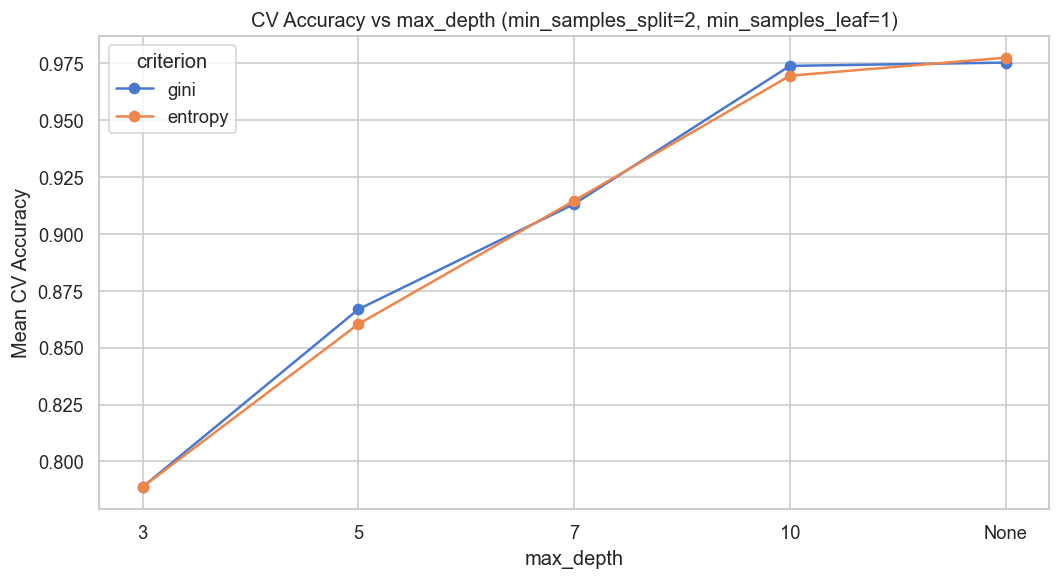

In [12]:
# Visualise effect of max_depth on CV accuracy (gini vs entropy)
results = pd.DataFrame(grid_search.cv_results_)

fig, ax = plt.subplots(figsize=(9, 5))
for criterion in ['gini', 'entropy']:
    subset = results[
        (results['param_criterion'] == criterion) &
        (results['param_min_samples_split'] == 2) &
        (results['param_min_samples_leaf'] == 1) &
        (results['param_max_features'].isna())
    ].copy()
    # Replace None with a numeric label for plotting
    subset['depth_label'] = subset['param_max_depth'].apply(lambda x: 'None' if x is None else str(x))
    ax.plot(subset['depth_label'], subset['mean_test_score'], marker='o', label=criterion)

ax.set_title('CV Accuracy vs max_depth (min_samples_split=2, min_samples_leaf=1)')
ax.set_xlabel('max_depth')
ax.set_ylabel('Mean CV Accuracy')
ax.legend(title='criterion')
plt.tight_layout()
plt.show()

## 7. Hyperparameter Tuning — RandomizedSearchCV

In [13]:
from scipy.stats import randint

param_dist = {
    'criterion':         ['gini', 'entropy'],
    'max_depth':         [3, 4, 5, 6, 7, 8, 10, 12, None],
    'min_samples_split': randint(2, 30),
    'min_samples_leaf':  randint(1, 15),
    'max_features':      [None, 'sqrt', 'log2']
}

rand_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=SEED),
    param_distributions=param_dist,
    n_iter=100,
    cv=5,
    scoring='accuracy',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)
rand_search.fit(X_train, y_train)

print('Best Parameters (Random):', rand_search.best_params_)
print(f'Best CV Accuracy (Random): {rand_search.best_score_:.4f}')

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best Parameters (Random): {'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2}
Best CV Accuracy (Random): 0.9653


            Method  CV Accuracy
          Baseline     0.975388
      GridSearchCV     0.977552
RandomizedSearchCV     0.965272


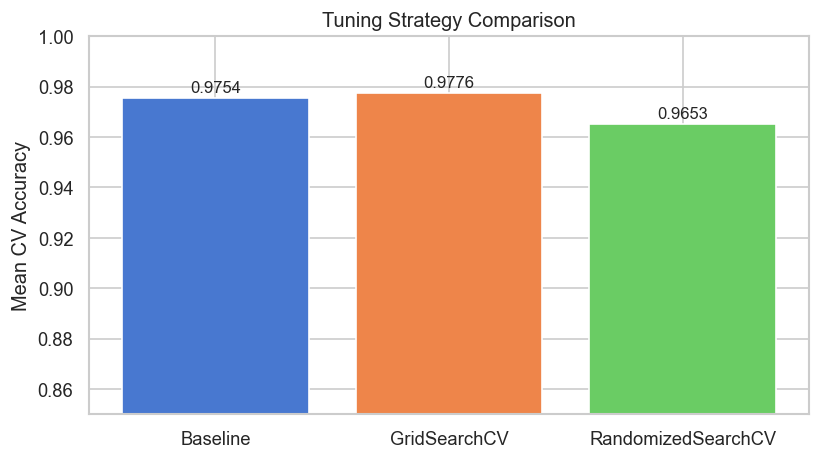

In [14]:
# Compare Grid vs Random search best CV scores
comparison = pd.DataFrame({
    'Method': ['Baseline', 'GridSearchCV', 'RandomizedSearchCV'],
    'CV Accuracy': [
        cv_scores.mean(),
        grid_search.best_score_,
        rand_search.best_score_
    ]
})
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(comparison['Method'], comparison['CV Accuracy'],
              color=sns.color_palette('muted', 3))
ax.set_ylim(0.85, 1.0)
ax.set_ylabel('Mean CV Accuracy')
ax.set_title('Tuning Strategy Comparison')
for bar, val in zip(bars, comparison['CV Accuracy']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## 8. Best Model Evaluation

In [15]:
# Select best model (highest CV accuracy between grid and random)
if grid_search.best_score_ >= rand_search.best_score_:
    best_model = grid_search.best_estimator_
    best_source = 'GridSearchCV'
else:
    best_model = rand_search.best_estimator_
    best_source = 'RandomizedSearchCV'

print(f'Best model from: {best_source}')
print(f'Parameters: {best_model.get_params()}')

y_pred_best = best_model.predict(X_test)
acc_best = accuracy_score(y_test, y_pred_best)
print(f'\nTest Accuracy: {acc_best:.4f}')
print(f'Tree Depth: {best_model.get_depth()}')
print(f'Number of Leaves: {best_model.get_n_leaves()}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred_best, target_names=le.classes_))

Best model from: GridSearchCV
Parameters: {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'entropy', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 42, 'splitter': 'best'}

Test Accuracy: 0.9913
Tree Depth: 12
Number of Leaves: 74

Classification Report:
              precision    recall  f1-score   support

         acc       0.99      0.97      0.98        77
        good       0.88      1.00      0.93        14
       unacc       1.00      1.00      1.00       242
       vgood       1.00      0.92      0.96        13

    accuracy                           0.99       346
   macro avg       0.97      0.97      0.97       346
weighted avg       0.99      0.99      0.99       346



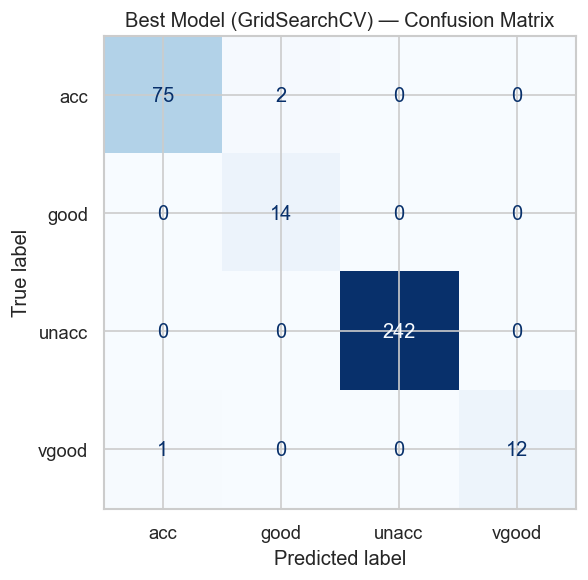

In [16]:
# Confusion matrix — best model
cm_best = confusion_matrix(y_test, y_pred_best)
disp_best = ConfusionMatrixDisplay(confusion_matrix=cm_best, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp_best.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Best Model ({best_source}) — Confusion Matrix')
plt.tight_layout()
plt.show()

In [17]:
# ROC-AUC (One-vs-Rest, macro average)
y_prob = best_model.predict_proba(X_test)
roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
print(f'ROC-AUC (OvR macro): {roc_auc:.4f}')

ROC-AUC (OvR macro): 0.9859


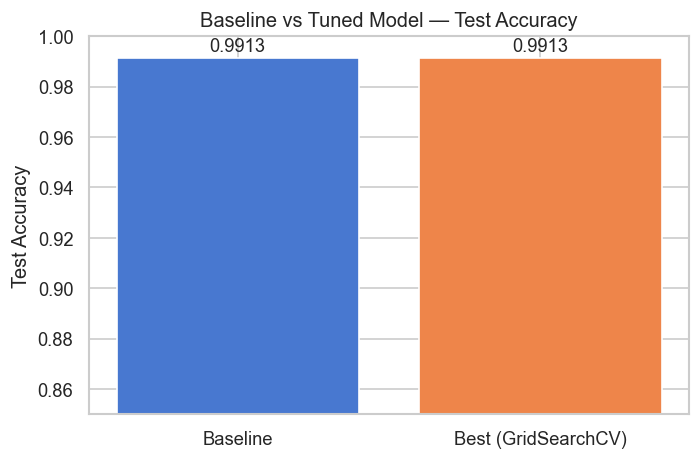

In [18]:
# Baseline vs Best model test accuracy comparison
fig, ax = plt.subplots(figsize=(6, 4))
labels = ['Baseline', f'Best ({best_source})']
values = [acc_base, acc_best]
bars = ax.bar(labels, values, color=sns.color_palette('muted', 2))
ax.set_ylim(0.85, 1.0)
ax.set_ylabel('Test Accuracy')
ax.set_title('Baseline vs Tuned Model — Test Accuracy')
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

## 9. Tree Visualisation

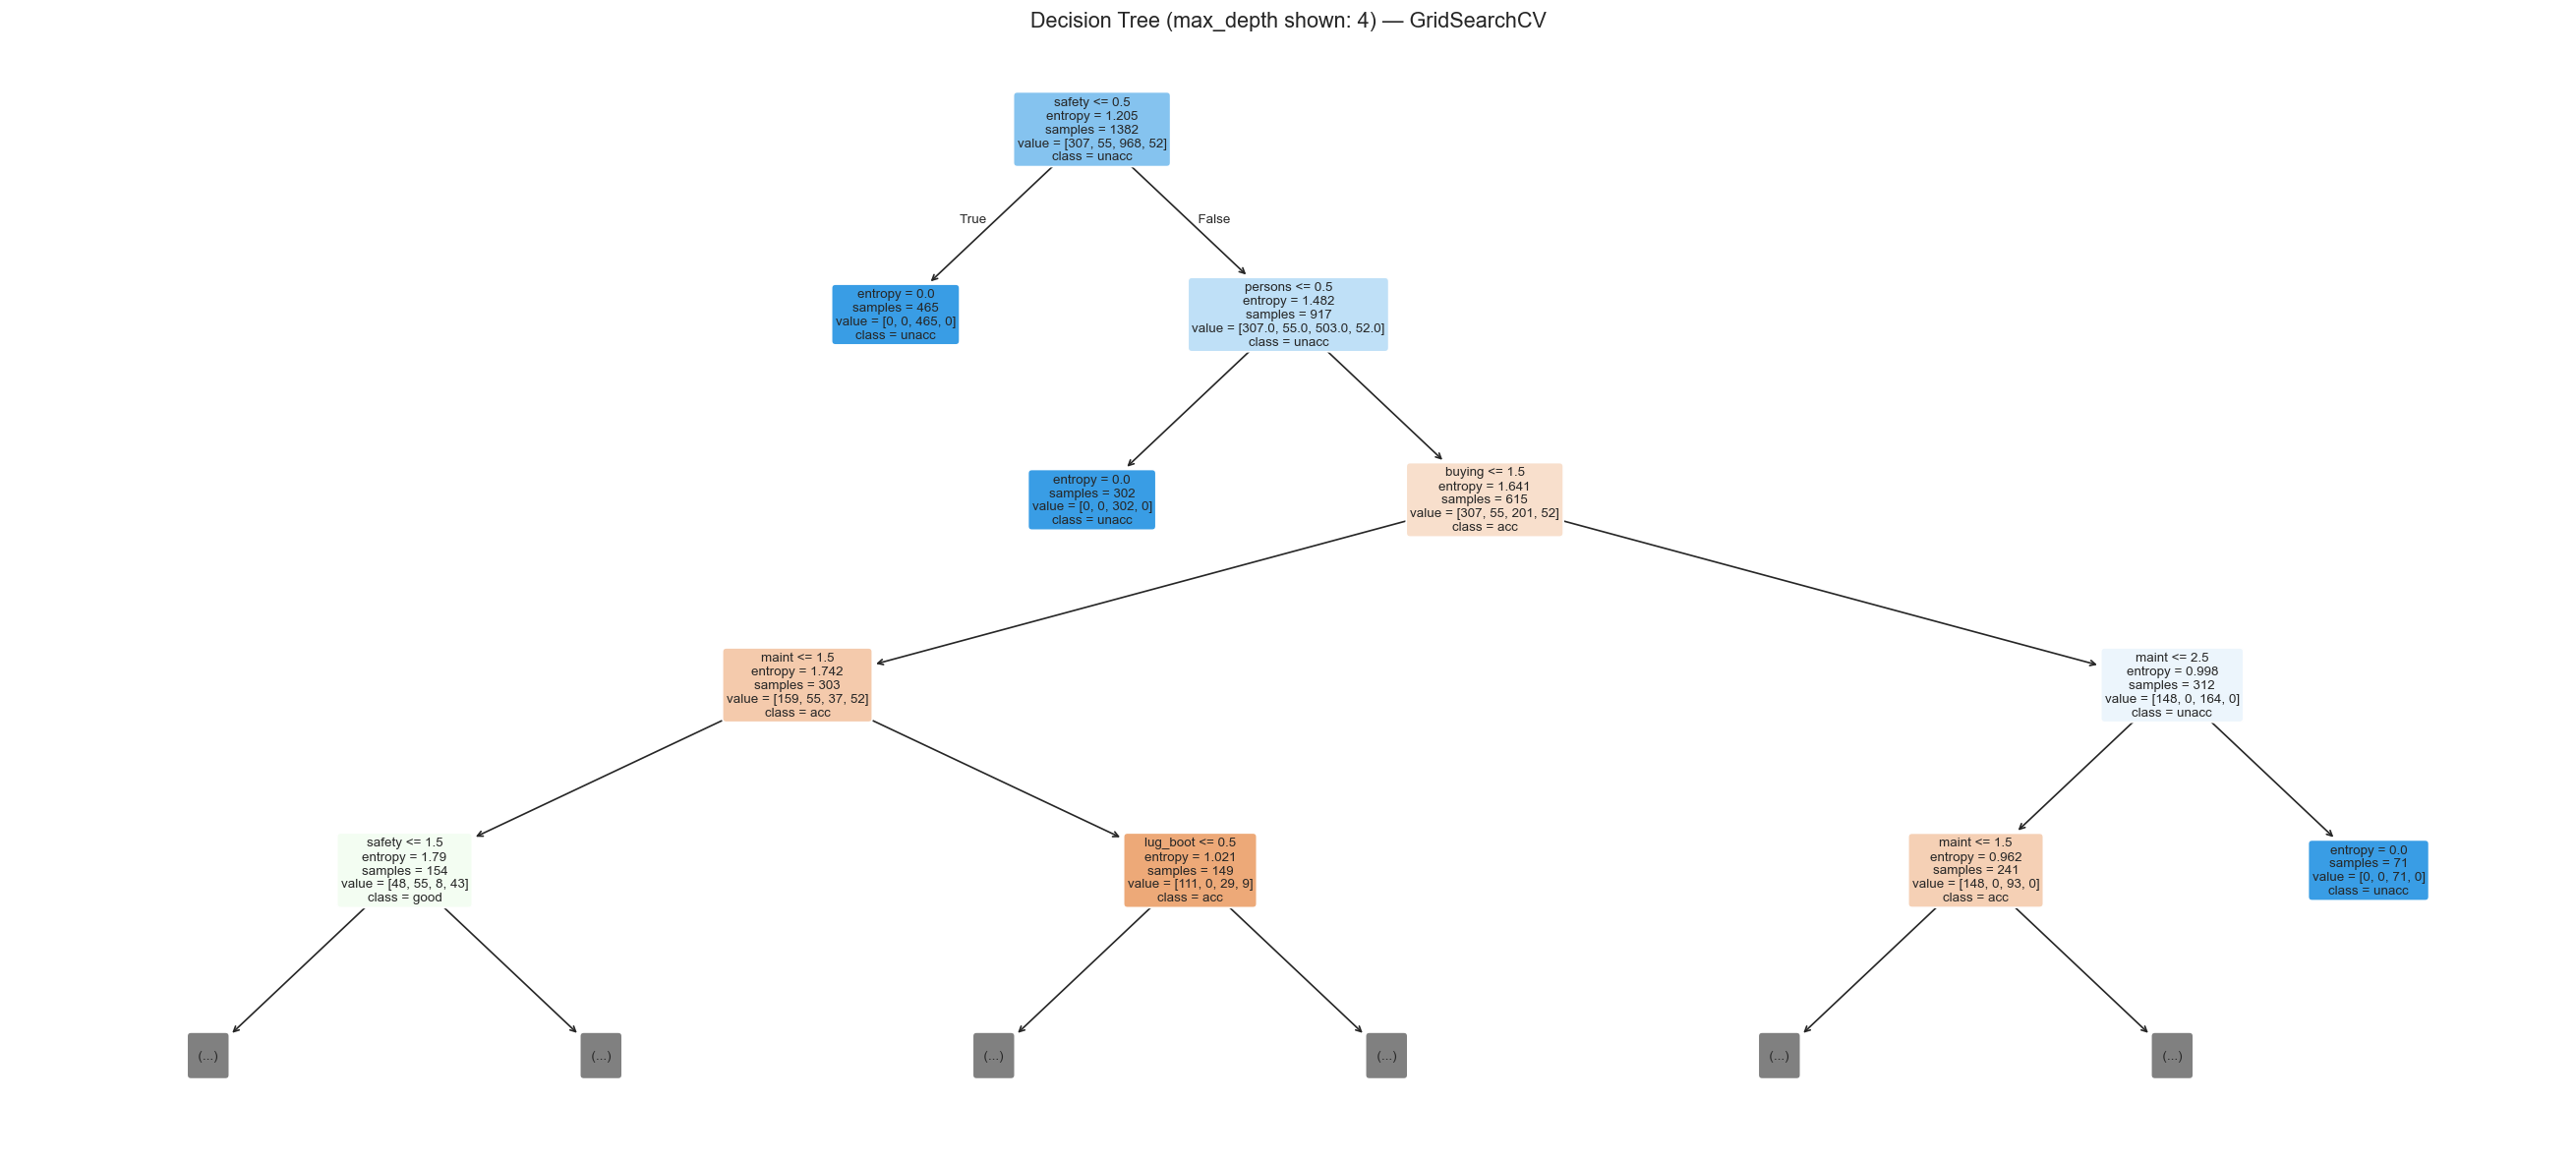

In [19]:
# Full tree plot (capped at depth 4 for readability)
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    best_model,
    feature_names=features,
    class_names=le.classes_,
    filled=True,
    rounded=True,
    max_depth=4,
    ax=ax,
    fontsize=8
)
ax.set_title(f'Decision Tree (max_depth shown: 4) — {best_source}', fontsize=13)
plt.tight_layout()
plt.show()

In [20]:
# Text representation of the tree (first 3 levels)
tree_rules = export_text(best_model, feature_names=features, max_depth=3)
print(tree_rules)

|--- safety <= 0.50
|   |--- class: 2
|--- safety >  0.50
|   |--- persons <= 0.50
|   |   |--- class: 2
|   |--- persons >  0.50
|   |   |--- buying <= 1.50
|   |   |   |--- maint <= 1.50
|   |   |   |   |--- truncated branch of depth 8
|   |   |   |--- maint >  1.50
|   |   |   |   |--- truncated branch of depth 9
|   |   |--- buying >  1.50
|   |   |   |--- maint <= 2.50
|   |   |   |   |--- truncated branch of depth 9
|   |   |   |--- maint >  2.50
|   |   |   |   |--- class: 2



## 10. Feature Importance

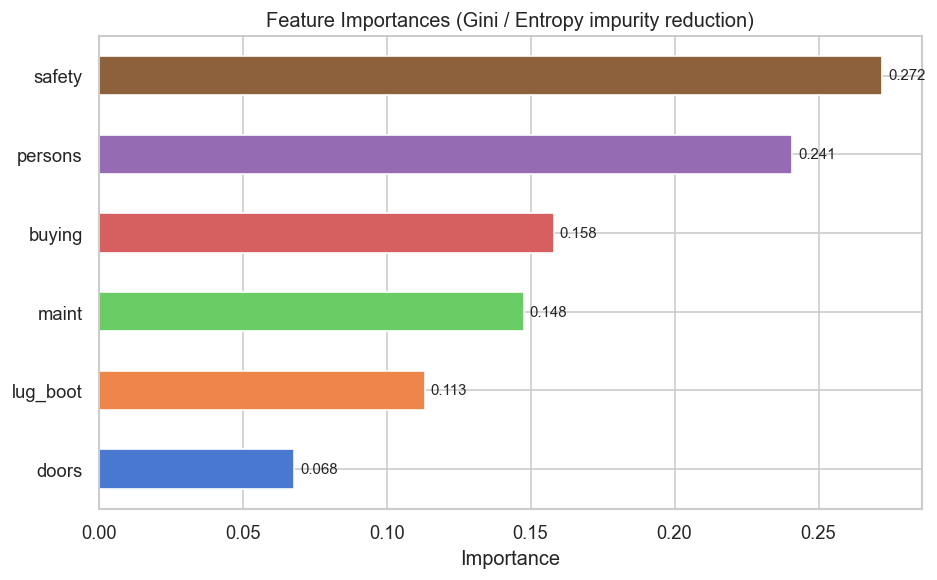

In [21]:
importances = pd.Series(best_model.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
importances.plot(kind='barh', ax=ax, color=sns.color_palette('muted', len(features)))
ax.set_title('Feature Importances (Gini / Entropy impurity reduction)')
ax.set_xlabel('Importance')
for i, v in enumerate(importances.values):
    ax.text(v + 0.002, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

## 11. Conclusions

- The Car Evaluation dataset is fully categorical and moderately imbalanced (`unacc` dominates at ~70%).
- Ordinal encoding preserving domain order (e.g. `low < med < high < vhigh`) is appropriate for decision trees on this dataset.
- The baseline `DecisionTreeClassifier` with default parameters already achieves strong accuracy, but tends to overfit (deep, many leaves).
- `GridSearchCV` and `RandomizedSearchCV` both improve generalisation by constraining depth and leaf size.
- `safety` and `persons` consistently rank as the most important features, aligning with domain intuition.
- The tuned model achieves high ROC-AUC (OvR macro), confirming good multi-class discrimination.
- `RandomizedSearchCV` is a practical alternative to full grid search when the parameter space is large, offering comparable results in less time.